# Gradient verification for the 1D - non reactive transport (diffusion + advection), permeability inversion from head observations 

The goal here is to verify the correctness of the adjoint state method in HYTEC by comparing the results with the demonstrator's which are considered as correct.

In [1]:
from pathlib import Path
import os
import logging
import copy
import time
from typing import Dict, Generator
import pyrtid
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
from pyrtid.utils import indices_to_node_number, node_number_to_indices
import nested_grid_plotter as ngp
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.animation import HTMLWriter
from IPython.display import HTML
import numpy as np

import pandas as pd
import scipy as sp
import gstools as gs
from pyrtid.utils import (
    NDArrayFloat,
    NDArrayInt,
    gen_random_ensemble,
    node_number_to_indices,
)

gs.config.USE_RUST = True  # Use the rust implementation of gstools

- Set-up logging level

In [2]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a logging test")

INFO:root:this is a logging test



- Check package/software versions

In [3]:
pyrtid.utils.show_versions()

INFO:root:Current version = 0.1.2

INFO:root:Used packages version:

INFO:root:iterative_ensemble_smoother = 0.1.1
INFO:root:gstools                     = 1.5.0
INFO:root:matplotlib                  = 3.7.1
INFO:root:nested_grid_plotter         = 0.1.0
INFO:root:numdiftools                 = 0.9.41
INFO:root:numpy                       = 1.24.0
INFO:root:pyesmda                     = 0.4.3
INFO:root:pypcga                      = 0.1.0
INFO:root:scipy                       = 1.10.1
INFO:root:sksparse                    = 0.4.12
INFO:root:stochopy                    = 2.3.0


- Create a directory to store the exported figures

In [4]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Define some configurations for the plots

In [5]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

## Forward problem

- Define a very simple pure diffusion case in 1D.

In [6]:
nx = 100  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 0.0001  # voxel dimension along the x axis
dy = 1.0  # voxel dimension along the y axis

# Time parameters
duration_in_d = 0  # duration in days
duration_in_s = duration_in_d * 3600 * 24
dt_init = 3600  # timestep in seconds
dt_max = dt_init * 2
dt_min = dt_init / 2

# Hydro parameters
k0 = 1e-2  # general permeability

# Values for the x axis ()meters
x_positions_in_meters: NDArrayFloat = np.arange(nx) * dx + dx / 2
storage_coefficient = 1e-4

flow_regime = "stationary"
crank_flow = 1.0

- x_coordinates array for the plots

In [7]:
x_coordinates = (np.arange(nx) + 0.5) * dx

- Three observation wells

In [8]:
observation_locations = [15, 30, 40, 70]

- Create an reference and an initial estimate distribution for the permebility

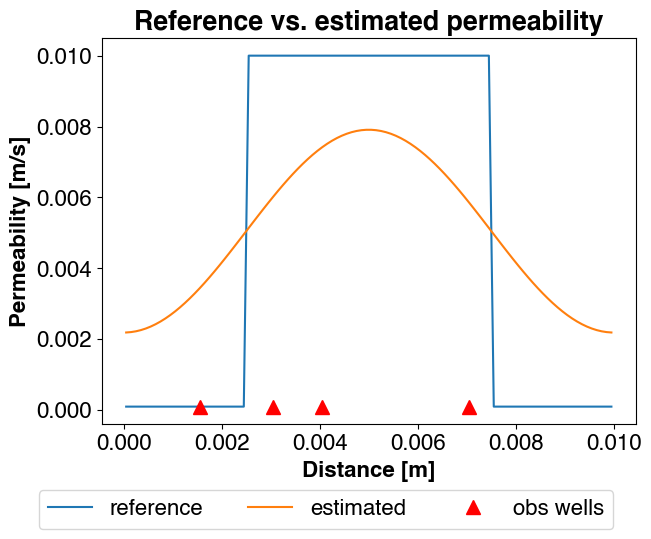

In [9]:
min_val = 1e-4
max_val = 1e-2

perm_reference = np.ones((nx, ny)) * min_val  # m2/s
perm_reference[25:-25, :] = max_val
perm_estimate: NDArrayFloat = sp.ndimage.gaussian_filter(perm_reference, 20)

plotter = ngp.NestedGridPlotter()
ax = plotter.ax_dict["ax1-1"]

ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Permeability [m/s]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("Reference vs. estimated permeability", fontweight="bold")
plotter.fig.set_facecolor("w")


ax.plot(x_positions_in_meters, perm_reference, label="reference")
ax.plot(x_positions_in_meters, perm_estimate, label="estimated")

# Add some vertical lines to indicate the well
for well_pos in observation_locations:
    ax.plot(
        (well_pos + 0.5) * dx,
        min_val,
        label="obs wells",
        marker="^",
        markersize=10,
        c="r",
        linestyle="none",
    )

plotter.add_fig_legend(ncol=3)

fname = "true_vs_estimated_initial_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

### Forward problem in PyRTID (python demonstrator)

In [10]:
# Simulation on 31 days. We use a 4h timestep.
time_params = dmfwd.TimeParameters(
    duration=duration_in_s, dt_init=dt_init, dt_max=dt_max, dt_min=dt_min
)
geometry = dmfwd.Geometry(nx=nx, ny=ny, dx=dx, dy=dy)
fl_params = dmfwd.FlowParameters(
    permeability=k0,
    regime={
        "stationary": dmfwd.FlowRegime.STATIONARY,
        "transient": dmfwd.FlowRegime.TRANSIENT,
    }[flow_regime],
    storage_coefficient=storage_coefficient,
    crank_nicolson=crank_flow,
)

base_model = dmfwd.ForwardModel(geometry, time_params, fl_params)

- Add boundary conditions and regional recharge

In [11]:
# Boundary conditions
# Left border (x = 0) at 10 m
base_model.add_boundary_conditions(dmfwd.ConstantHead(span=(slice(0, 1), slice(None))))
base_model.fl_model.set_initial_head(10.0, span=(slice(0, 1), slice(None)))
# Right border (x = xmax) at 2 m
base_model.add_boundary_conditions(
    dmfwd.ConstantHead(span=(slice(nx - 1, nx), slice(None)))
)
base_model.fl_model.set_initial_head(2.0, span=(slice(nx - 1, nx), slice(None)))

- Create two models with different permeabilities

In [12]:
# copy the base model
model_reference = copy.deepcopy(base_model)
# update permeability
model_reference.fl_model.permeability = perm_reference
# solve the flow problem
dmfwd.ForwardSolver(model_reference).solve()

# copy the base model
model_estimate = copy.deepcopy(base_model)
# update permeability
model_estimate.fl_model.permeability[:, :] = perm_estimate
# solve the flow problem
dmfwd.ForwardSolver(model_estimate).solve()

### Comparison between hytec and the demonstrator for the forward problem

- Plot the forward results

In [13]:
model_reference.fl_model.head.shape

(100, 1, 1)

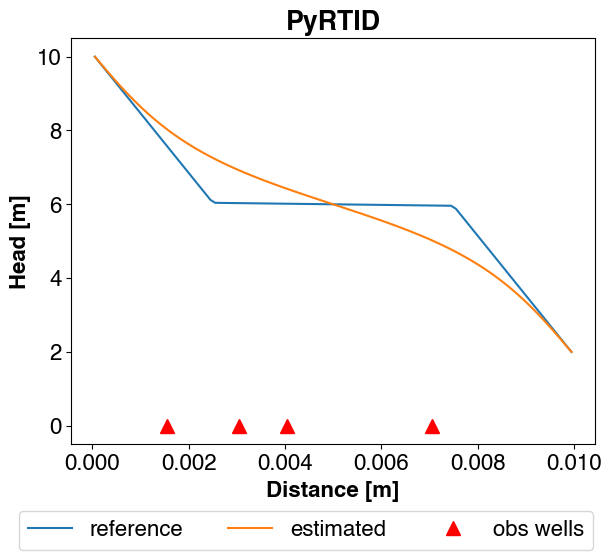

In [14]:
plotter = ngp.NestedGridPlotter(
    fig_params={"figsize": (6, 5)},
    subplots_mosaic_params={
        "fig1": {"mosaic": [["ax1-1"]], "sharex": True, "sharey": True}
    },
)
ax = plotter.ax_dict["ax1-1"]
ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Head [m]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("HYTEC", fontweight="bold")

ax = plotter.ax_dict["ax1-1"]
ax.plot(
    x_positions_in_meters, model_reference.fl_model.head[:, 0, 0], label="reference"
)
ax.plot(x_positions_in_meters, model_estimate.fl_model.head[:, 0, 0], label="estimated")
ax.set_xlabel("Distance [m]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("PyRTID", fontweight="bold")


# Add some vertical lines to indicate the well
for ax in plotter.ax_dict.values():
    for well_pos in observation_locations:
        ax.plot(
            (well_pos + 0.5) * dx,
            min_val,
            label="obs wells",
            marker="^",
            markersize=10,
            c="r",
            linestyle="none",
        )

plotter.add_fig_legend(ncol=3)

fname = "true_vs_estimated_initial_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

## Inversion

- Create a function to add some noise to the observations

In [15]:
noise_std = 0.15  # This is an absolute value
rng = np.random.default_rng(2021)


def get_white_noise(shape: int) -> NDArrayFloat:
    """Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    return rng.normal(0.0, noise_std, shape)

- Check the intensity of the noise

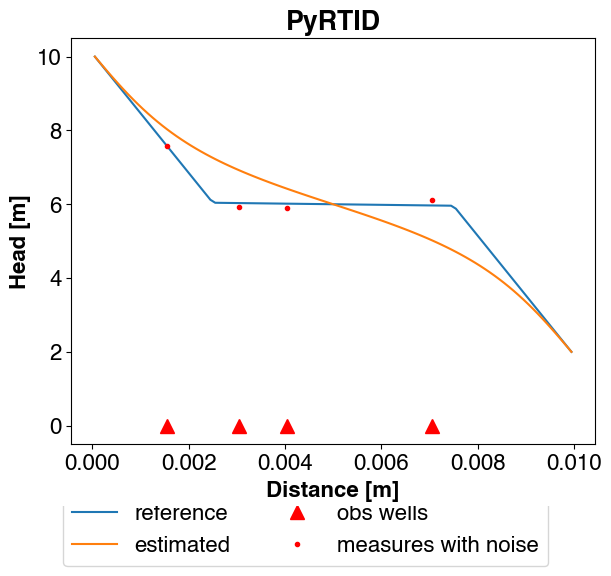

In [16]:
# Generate a white noise
obs_noise: NDArrayFloat = get_white_noise(
    model_reference.fl_model.head[observation_locations, 0, -1].shape[0]
)

# Plot the observations with the white noise
# plotter.ax_dict["ax1-1"].plot(
#     x_coordinates[observation_locations],
#     head_reference_hytec[observation_locations, 0, 0, 0] + obs_noise,
#     marker=".",
#     c="r",
#     linestyle="none",
#     label="measures with noise",
# )
plotter.ax_dict["ax1-1"].plot(
    x_coordinates[observation_locations],
    model_reference.fl_model.head[observation_locations, 0, 0] + obs_noise,
    marker=".",
    c="r",
    linestyle="none",
    label="measures with noise",
)
plotter.add_fig_legend(ncol=2)
plotter.fig

### Demonstrator


In [17]:
np.zeros((1), dtype=np.float_)

array([0.])

In [18]:
def inverse_function(x: NDArrayFloat) -> NDArrayFloat:
    """Return 1/x."""
    return 1 / x


param = dminv.AdjustableParameter(
    name=dminv.ParameterName.PERMEABILITY,
    lbound=min_val,
    ubound=max_val,
    preconditioner=np.log,
    preconditioner_1st_derivative=inverse_function,
    backconditioner=np.exp,
)

observables = []
for i, node_id in enumerate(observation_locations):
    vals: NDArrayFloat = model_reference.fl_model.head[node_id, 0, :] + obs_noise[i]
    timesteps = np.zeros((1), dtype=np.float_)
    observables.append(
        dminv.Observable(
            state_variable=dminv.StateVariable.HEAD,
            node_indices=node_id,
            times=timesteps,
            values=vals,
            uncertainties=noise_std,
        )
    )

# Create an executor to keep track of the adjoint model
solver_config = dminv.ScipySolverConfig(
    solver_name="L-BFGS-B",
    solver_options={"maxfun": 20, "maxiter": 20, "ftol": 1e-4, "gtol": 1e-4},
    is_check_gradient=True,
)
model_adjusted = copy.deepcopy(model_estimate)
inverse_model = dminv.InverseModel(param, observables)
executor = dminv.ScipyInversionExecutor(model_adjusted, inverse_model, solver_config)

is_grad_ok = executor.is_adjoint_gradient_correct()
print("Is the gradient correct: ", is_grad_ok)

Is the gradient correct:  False


- Compute the first objective function

In [19]:
executor.scaled_loss_function(param.preconditioner(param.values))

INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 14.929105784980267
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.06698324832061077
INFO:root:Loss (scaled)         = 1.0



1.0

In [20]:
obs = observables[0]

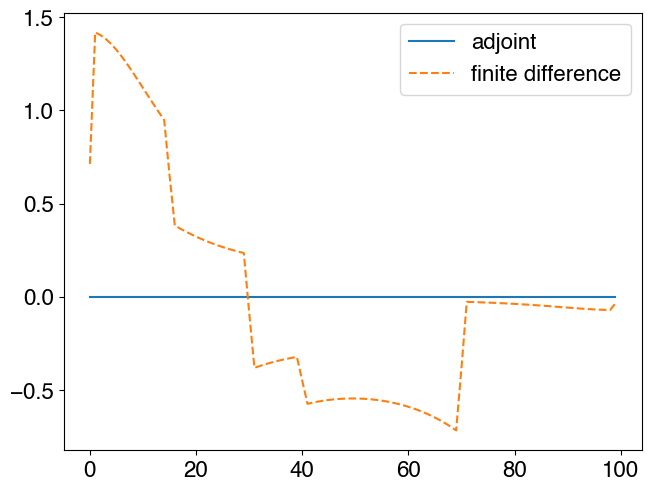

In [21]:
plt.plot(param.archived_adjoint_gradients[0], label="adjoint")
plt.plot(param.archived_fd_gradients[0], label="finite difference", linestyle="--")
plt.legend()

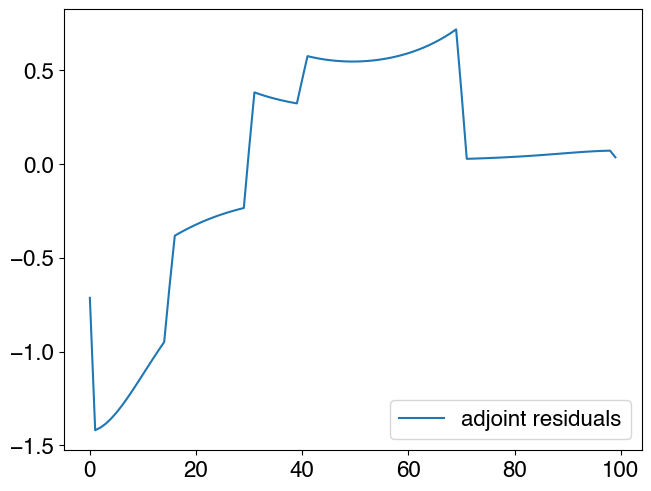

In [22]:
plt.plot(
    param.archived_adjoint_gradients[0] - param.archived_fd_gradients[0],
    label="adjoint residuals",
)
plt.legend()

### HYTEC

In [23]:
# 1) Copy the base simulation
simu_inverse = copy.deepcopy(simu_estimate)
simu_inverse.update_root_and_name(new_root="simu_inverse", new_name="simu_inverse")

# 2) Add the observation wells
for count, ix in enumerate(observation_locations):
    x = (ix + 0.5) * dx
    zone_name = f"well_{ix}"
    # Use the demonstrator values
    vals = np.array(model_reference.fl_model.head[ix, 0, :] + obs_noise[count])

    # Add the observables for the area
    obs = Observable(
        zone_name=zone.name,
        state_variable="head",
        units="m",
        timesteps=grid_sample_times[:],
        time_units="s",
        obs_type=ObservationType.GRID,
        values=vals,
        uncertainties=noise_std,
        node_numbers=[ix] * vals.size,
    )
    simu_inverse.register_observable(
        zone_name, obs, obs_file_path=f"observables/{zone_name}_o.dat"
    )

# 3) Update the htc file with some options
inv_model = hymd.InverseModel(
    hymd.OptimizationStatus("enabled"),
    hymd.OptimizationSolverConfig(
        "lbfgsb", hymd.AdjointStateStatus("enabled"), hymd.FdGradientCheck("initial")
    ),
    hymd.AdjustedParameterConfig(
        "permeability",
        hymd.Lbound(min_val, units="m/s"),
        hymd.Ubound(max_val, units="m/s"),
        hymd.Preconditioner("logarithmic"),
    ),
)
simu_inverse.model.add_sub_item(inv_model)

# number of samples on the adjoint variables
simu_inverse.model.get_sub_model(hymd.SamplingModel).add_sub_item(
    hymd.AdjointGridSampling(nt)
)

# 4)Write the input files
simu_inverse.write_input_files()

runner.run(simu_inverse)

# 7) Read results
simu_inverse.read_hytec_results()  # This fails if not results have been written

NameError: name 'simu_estimate' is not defined

In [ ]:
obs.time_units

's'

- Plot the head field (to be sure it has been correctly reinitialized)

(100, 1, 1, 2)


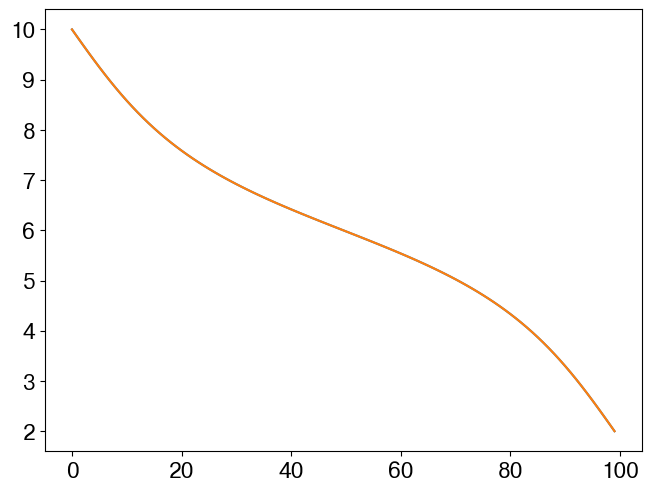

In [ ]:
inverse_heads_hytec = simu_inverse.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)

print(inverse_heads_hytec.shape)

plt.plot(inverse_heads_hytec[:, 0, 0, 0])
plt.plot(inverse_heads_hytec[:, 0, 0, -1])

- Extract the adjoint variables computed for the first gradient

In [ ]:
print(f"columns = {simu_inverse.handlers.results.optim_res.adjoint_var_columns}")

columns = ['timestep', 'Zones', 'node-number []', 'adjoint-variable{head} []', 'x-distance']


In [ ]:
adj_head_hytec = simu_inverse.handlers.results.extract_field_from_adj_var_res(
    field="adjoint-variable{head} []", nx=nx
)
adj_head_hytec.shape

(100, 1, 1, 2)

In [ ]:
executor.scaled_loss_function(np.log(param.values))

INFO:root:- Running forward model # 3
INFO:root:- Run # 3 over
INFO:root:Loss (obs fit)        = 119.43284518138694
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.008372906117074174
INFO:root:Loss (scaled)         = 0.9999999999988075



0.9999999999988075

### Results comparison

The adjoint concentrations should be quite the same both in shape and intensity.

In [ ]:
adj_head_hytec[:, 0, 0, 0]

array([ 0.        ,  1.67699556,  3.34127799,  4.98484511,  6.60036423,
        8.1813654 ,  9.72238992, 11.21903571, 12.66794887, 14.06680354,
       15.41422048, 16.70966024, 17.95330285, 19.14592415, 20.28877632,
       21.38347778, 21.84372045, 22.28456368, 22.70696719, 23.11191596,
       23.50040043, 23.8734012 , 24.23187757, 24.57675931, 24.90894095,
       25.22927829, 25.53858637, 25.8376388 , 26.127168  , 26.40786618,
       26.68038672, 26.22401833, 25.7796721 , 25.34640317, 24.92331946,
       24.50957781, 24.10438015, 23.70696983, 23.31662797, 22.93266995,
       22.55444213, 21.87210706, 21.19800651, 20.53108043, 19.87030315,
       19.2146811 , 18.56324576, 17.91504625, 17.26914711, 16.62462384,
       15.98055845, 15.33603517, 14.69013602, 14.0419365 , 13.39050114,
       12.73487908, 12.07410176, 11.40717566, 10.73307507, 10.05073996,
        9.35907065,  8.65692247,  7.94310006,  7.21635148,  6.47536212,
        5.71874824,  4.94505044,  4.1527268 ,  3.34014595,  2.50

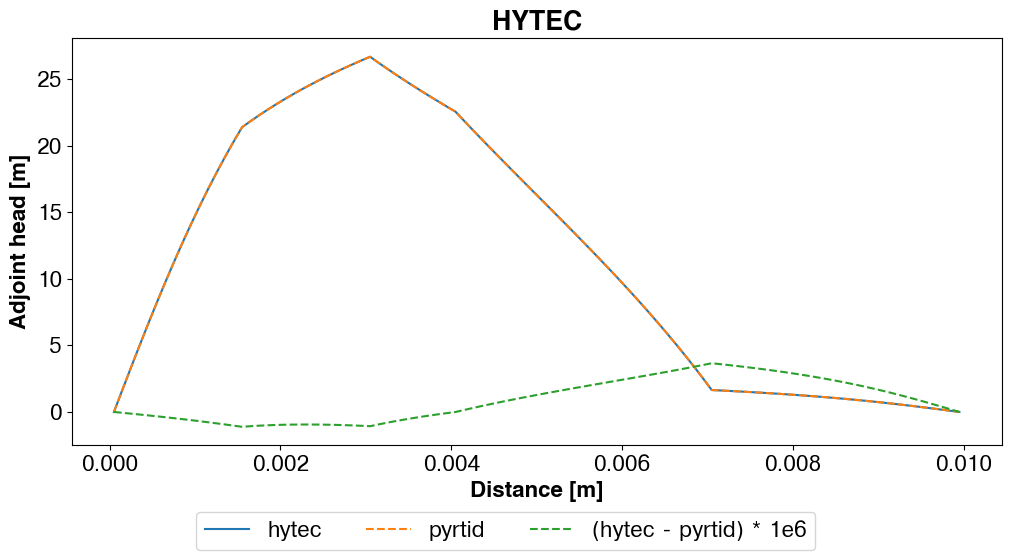

In [ ]:
plotter = ngp.NestedGridPlotter(
    fig_params={"figsize": (10, 5)},
)
ax = plotter.ax_dict["ax1-1"]
ax.plot(x_positions_in_meters, adj_head_hytec[:, 0, 0, 0], label="hytec")
ax.plot(
    x_positions_in_meters,
    executor.adj_model.a_fl_model.a_head[:, 0, 0],
    label="pyrtid",
    linestyle="--",
)
ax.plot(
    x_positions_in_meters,
    (adj_head_hytec[:, 0, 0, 0] - executor.adj_model.a_fl_model.a_head[:, 0, 0]) * 1e6,
    label="(hytec - pyrtid) * 1e6",
    linestyle="--",
)
ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Adjoint head [m]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("HYTEC", fontweight="bold")


# Add some vertical lines to indicate the well

plotter.add_fig_legend(ncol=3)

fname = "true_vs_estimated_initial_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Get the gradients by the adjoint method and finite differences

In [ ]:
# Get the HYTEC  Adj gradient
hytec_fd_gradient = simu_inverse.handlers.results.optim_res.fd_gradients[0]
hytec_adjoint_gradient = simu_inverse.handlers.results.optim_res.adjoint_gradients[0]

In [ ]:
simu_inverse.handlers.results.optim_res.adjoint_gradients

[    node-number  x-distance     value parameter-name
 0           0.0     0.00005  0.047766   permeability
 1           1.0     0.00015  0.095045   permeability
 2           2.0     0.00025  0.094088   permeability
 3           3.0     0.00035  0.092691   permeability
 4           4.0     0.00045  0.090900   permeability
 ..          ...         ...       ...            ...
 95         95.0     0.00955 -0.004561   permeability
 96         96.0     0.00965 -0.004651   permeability
 97         97.0     0.00975 -0.004721   permeability
 98         98.0     0.00985 -0.004769   permeability
 99         99.0     0.00995 -0.002397   permeability
 
 [100 rows x 4 columns]]

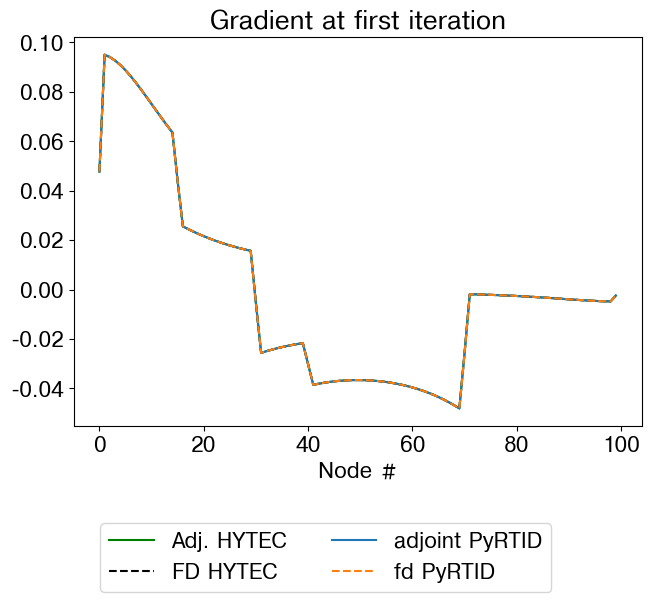

In [ ]:
# Here comes the python code
plotter = ngp.NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
# hytec
ax.plot(hytec_adjoint_gradient["value"], label="Adj. HYTEC", c="g")
ax.plot(hytec_fd_gradient["value"], label="FD HYTEC", c="k", linestyle="--")
# pyrtid
ax.plot(
    param.archived_adjoint_gradients[0] * executor.inv_model.scaling_factor,
    label="adjoint PyRTID",
    linestyle="-",
)
ax.plot(
    param.archived_fd_gradients[0] * executor.inv_model.scaling_factor,
    label="fd PyRTID",
    linestyle="--",
)


ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_dem_vs_hytec_adj_vs_df_1d_diffusion"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

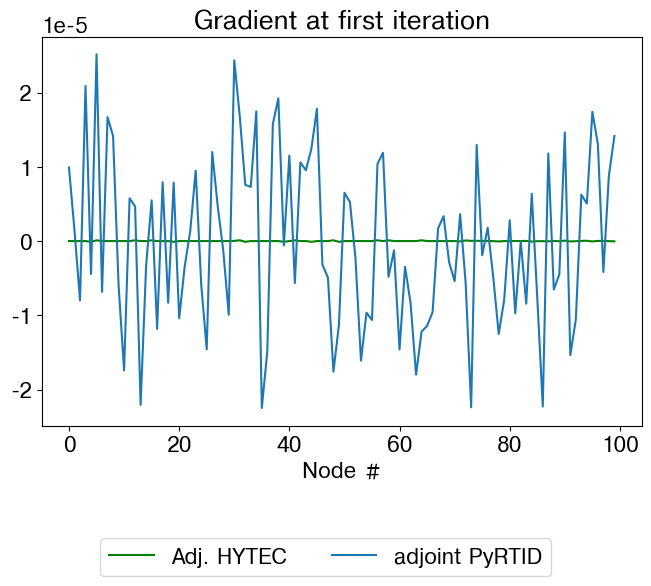

In [ ]:
# Here comes the python code
plotter = ngp.NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
# hytec
ax.plot(
    hytec_adjoint_gradient["value"] - hytec_fd_gradient["value"],
    label="Adj. HYTEC",
    c="g",
)
# pyrtid
ax.plot(
    param.archived_adjoint_gradients[0] - param.archived_fd_gradients[0],
    label="adjoint PyRTID",
    linestyle="-",
)

ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_dem_vs_hytec_adj_vs_df_1d_diffusion"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)